In [2]:
import jieba
import jieba.posseg as pseg

In [3]:
content = "我爱自然语言处理"
res = jieba.lcut(content)
print(res)
res = pseg.lcut(content)
print(res)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/zx/8_8_sz9s72752fqdhhskwcl40000gn/T/jieba.cache
Loading model cost 0.229 seconds.
Prefix dict has been built successfully.


['我', '爱', '自然语言', '处理']
[pair('我', 'r'), pair('爱', 'v'), pair('自然语言', 'l'), pair('处理', 'v')]


In [4]:
# tokenizer onehot encoding

from tensorflow.keras.preprocessing.text import Tokenizer
import joblib

vocabs = {"周杰伦", "陈奕迅", "王力宏", "李宗盛", "吴亦凡", "鹿晗"}
tokenizer = Tokenizer()
tokenizer.fit_on_texts(vocabs)
print(tokenizer.word_index)
print(tokenizer.index_word)

for vocab in vocabs:
    onehot = [0] * len(vocabs)
    idx = tokenizer.word_index[vocab] - 1
    onehot[idx] = 1
    print(f'vocab: {onehot}')

joblib.dump(tokenizer, './model/tokenizer.joblib')
print('tokenizer saved!')

vocabs = vocabs = {"周杰伦", "陈奕迅", "王力宏", "李宗盛", "吴亦凡", "鹿晗"}
tokenizer = joblib.load('./model/tokenizer.joblib')
token = '王力宏'
onehot = [0] * len(vocabs)
idx = tokenizer.word_index[token] - 1
onehot[idx] = 1
print(f"token's onehot: {onehot}")


{'王力宏': 1, '鹿晗': 2, '陈奕迅': 3, '吴亦凡': 4, '周杰伦': 5, '李宗盛': 6}
{1: '王力宏', 2: '鹿晗', 3: '陈奕迅', 4: '吴亦凡', 5: '周杰伦', 6: '李宗盛'}
vocab: [1, 0, 0, 0, 0, 0]
vocab: [0, 1, 0, 0, 0, 0]
vocab: [0, 0, 1, 0, 0, 0]
vocab: [0, 0, 0, 1, 0, 0]
vocab: [0, 0, 0, 0, 1, 0]
vocab: [0, 0, 0, 0, 0, 1]
tokenizer saved!
token's onehot: [1, 0, 0, 0, 0, 0]


In [5]:
import jieba
import torch
import torch.nn as nn
from tensorflow.keras.preprocessing.text import Tokenizer

sentence1 = '莱斯大学位于休斯顿'
sentence2 = '我爱自然语言处理'
sentences = [sentence1, sentence2]

tokens_lst = []
for s in sentences:
    tokens_lst.append(jieba.lcut(s))
print(tokens_lst)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(tokens_lst)
print(tokenizer.word_index)
print(tokenizer.index_word)

seq_ids = tokenizer.texts_to_sequences(tokens_lst)
print(seq_ids)

words = tokenizer.word_index.keys()
print(words)

embed = nn.Embedding(num_embeddings=len(words), embedding_dim=8)
print(embed.weight)

for idx in range(len(tokenizer.index_word)):
    output = embed(torch.tensor(idx))
    print(f'{tokenizer.index_word[idx + 1]}: {output}')





[['莱斯', '大学', '位于', '休斯顿'], ['我', '爱', '自然语言', '处理']]
{'莱斯': 1, '大学': 2, '位于': 3, '休斯顿': 4, '我': 5, '爱': 6, '自然语言': 7, '处理': 8}
{1: '莱斯', 2: '大学', 3: '位于', 4: '休斯顿', 5: '我', 6: '爱', 7: '自然语言', 8: '处理'}
[[1, 2, 3, 4], [5, 6, 7, 8]]
dict_keys(['莱斯', '大学', '位于', '休斯顿', '我', '爱', '自然语言', '处理'])
Parameter containing:
tensor([[ 0.3087,  0.7182, -1.2532,  1.0547,  1.2910, -0.7695, -0.7637, -0.3480],
        [ 1.7059, -0.8304, -0.9888, -0.2709, -0.0582,  0.1925,  0.1050,  0.1755],
        [-0.7137,  0.0446,  0.7687,  1.3774, -0.3069,  1.0141,  0.4708,  0.4852],
        [-0.2044,  0.4512,  0.7177,  1.2330, -0.8790,  0.0670,  0.0535,  0.1811],
        [ 1.1752,  0.6643, -1.2565,  0.2751,  0.0679,  0.4282,  0.2795, -1.6618],
        [ 1.2726,  0.6317,  0.3727, -0.1271,  2.1065, -2.4803, -0.1051,  0.6724],
        [ 1.9316, -0.9183, -0.6536,  1.8618, -0.6936,  0.0488,  1.4418, -0.6762],
        [-2.2834,  0.6457,  0.8572,  0.1572, -0.6124,  0.8484,  1.1745, -0.5875]],
       requires_grad=True)
莱斯

<class 'pandas.DataFrame'>
RangeIndex: 2960 entries, 0 to 2959
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  2960 non-null   str  
 1   label     2960 non-null   int64
dtypes: int64(1), str(1)
memory usage: 46.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sentence  1000 non-null   str  
 1   label     1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


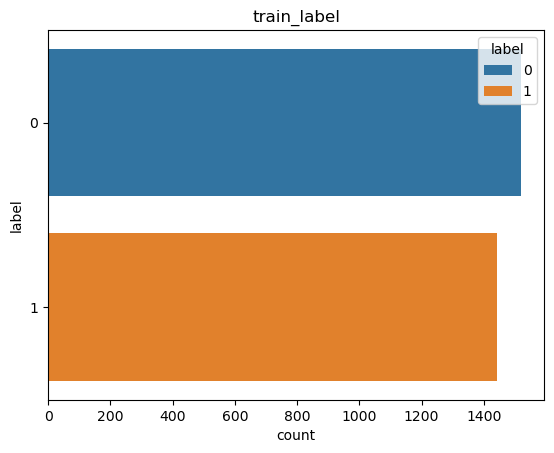

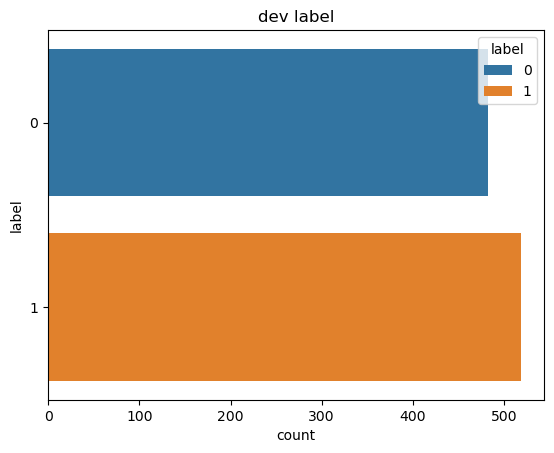

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

train_data = pd.read_csv('./data/cn_data/train.tsv', sep='\t')
dev_data = pd.read_csv('./data/cn_data/dev.tsv', sep='\t')
train_data.info()
dev_data.info()

sns.countplot(y='label', data=train_data, hue='label')
plt.title('train_label')
plt.show()

sns.countplot(y='label', data=dev_data, hue='label')
plt.title('dev label')
plt.show()

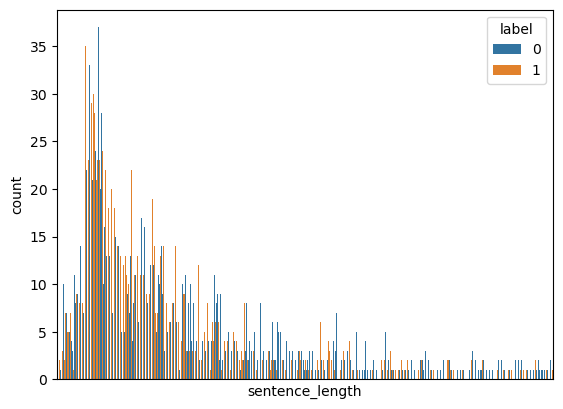

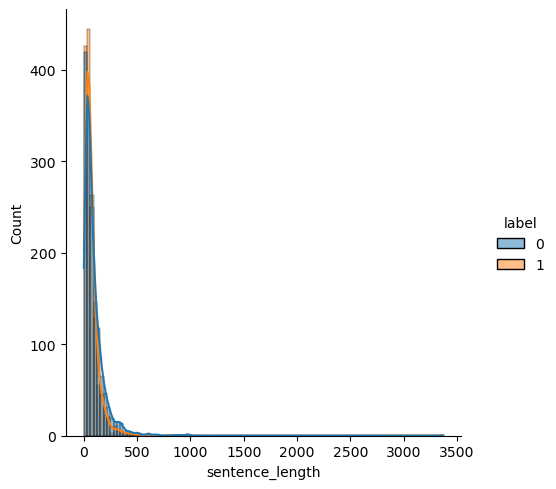

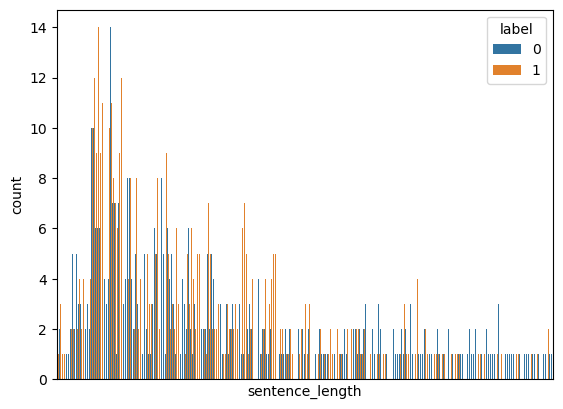

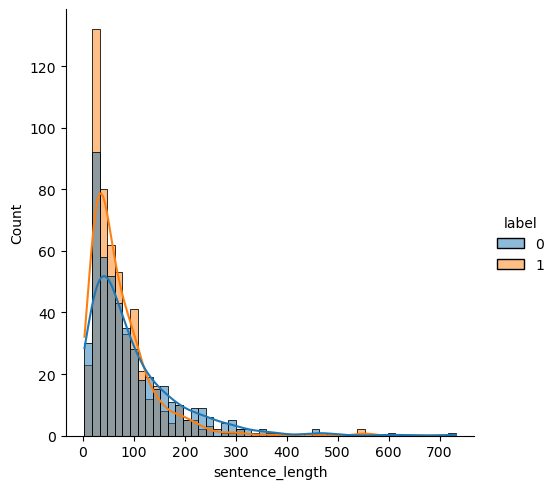

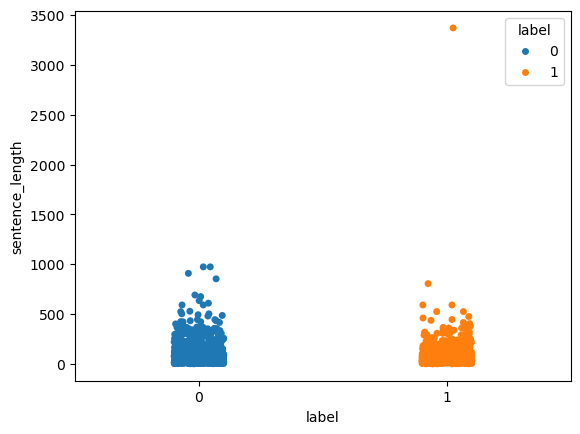

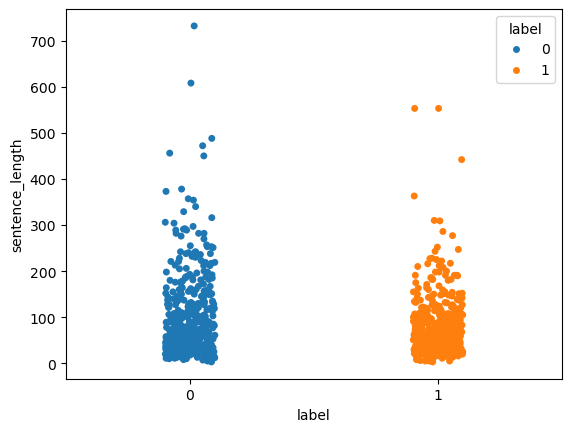

In [7]:
train_data['sentence_length'] = list(map(lambda x: len(x), train_data['sentence']))
dev_data['sentence_length'] = list(map(lambda x: len(x), dev_data['sentence']))
# print(train_data)

sns.countplot(x='sentence_length', data=train_data, hue='label')
plt.xticks([])
plt.show()

sns.displot(x='sentence_length', data=train_data, kind='hist', hue='label', kde=True)
plt.show()

sns.countplot(x='sentence_length', data=dev_data, hue='label')
plt.xticks([])
plt.show()

sns.displot(x='sentence_length', data=dev_data, kind='hist', hue='label', kde=True)
plt.show()

sns.stripplot(x='label', y='sentence_length', data=train_data, hue='label')
plt.show()

sns.stripplot(x='label', y='sentence_length', data=dev_data, hue='label')
plt.show()


In [8]:
from itertools import chain

train_tokens = set(chain(*map(lambda x: jieba.lcut(x), train_data['sentence'])))
print(train_tokens)
print(len(train_tokens))
dev_tokens = set(chain(*map(lambda x: jieba.lcut(x), dev_data['sentence'])))
print(dev_tokens)
print(len(dev_tokens))


{'不逊于', '一清二楚', '522', '不', '磁卡', '竟然', '厚', '算啦', '三十元', '时列', '允许', '连同', '俯瞰', '大不了', '500M', '厦大', '航班', '搬到', '明黄', '踹', '北路', '不通', '流畅', '经过', '小点心', '轰鸣', '像是', '水洗', 'ikea', '同样', '刚住', '家里', '傲慢无礼', '开得', '争辩', '坐人', '冰雪', '不严', '投诉无门', '机子', '索要', '裝', '见过', '平反', '08', '几百米', '得逞', '点中', '想必', '好久没', '仅此而已', '老式', '灯罩', '如果说', '关了', '西湖', '奇迹', '不正', '接线员', '更是', '胡乱', '几千块', '另一家', '悄悄地', '接站', '真烦', '不台', '凸出', '打法', '晚到', 'excellent', '王府', '人性', '到弥墩', '打入', '差强人意', '下不去', '有够', '问', '浩浩荡荡', '白给', '时酒', '填补', '狗来', '雙', '挣', '提供', '糖霜', '面包房', '强多', '最可气', '美食街', 'PANDA', '开店', '欣赏', '格林豪', '不入流', '發電機', '完事', '较', '情不愿', '居住', '熟', '床头柜', '气', '简洁', '如期', 'AmberleyHotel', '头上', '之星', '滚', '床铺', '想不道', '有海', '极小', '体臭味', '摸清', '四间', '延后', '失望', '甚麼', '恭维', '离去', '上要', '姓名', '做成', '入宿', '比美', '小楼', '太坑', '门', '16', '糟蹋', '茶杯', '不住', '饭店', '门卫', '大巴', '池中', '街边', '终点', '如新', '暗暗', '扑克', '房拼', '怡东', '一提', '看得出来', '西红柿', '排除', '1.3', '友善', '留下', '很美', '真是', '门脸', '刀', '缝隙',

['好', '好', '好', '豪华', '重新', '方便', '小', '干净', '整洁', '高', '旧', '小', '不错', '热闹', '很好', '小', '便宜', '少', '好', '方便', '窄', '老', '近', '高', '好', '一般', '干净', '近', '便利', '不错', '连续', '旧', '好', '勤快', '好', '方便', '豪华', '不大', '干净', '不错', '好', '合适', '很大', '干净', '不错', '整洁', '新', '不错', '挺大', '大', '不错', '远', '不错', '挺好吃', '方便', '大', '好', '小', '热', '方便', '紧', '不错', '不错', '干净', '好', '一般', '简单', '好', '一般', '差', '小', '好', '不足', '不错', '大', '不错', '不错', '不错', '旧', '小', '干净', '良好', '好', '舒服', '敏感', '不错', '方便', '远', '一般', '不错', '不错', '方便', '干静', '宽敞', '好', '方便', '方便', '老', '方便', '大', '宽敞', '不错', '近', '方便', '差', '好', '难吃', '好', '小', '大', '豪华', '先进', '先进', '冷', '高', '好', '旧', '不错', '干净', '好', '好', '不错', '差', '惊喜', '小', '干净', '整洁', '不错', '愉快', '旧', '不错', '太软', '干净', '最大', '不错', '不错', '好', '不错', '远', '近', '最好', '好', '方便', '简单', '高', '不错', '早', '较大', '最好', '一般', '好', '旺', '浓烈', '小', '好', '舒畅', '最绝', '不错', '不错', '旧', '不错', '显贵', '小', '不错', '大', '爽快', '方便', '方便', '近', '不错', '很大', '旧', '高', '蓝', '蓝', '亲切', '好', '好', '细致', 

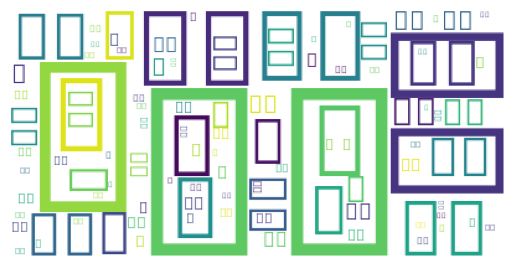

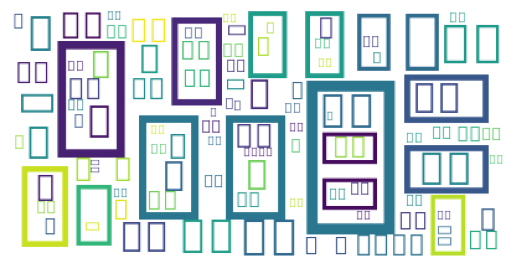

In [10]:
from wordcloud import WordCloud

def get_a_lst(sentence):
    res = []
    for token in pseg.lcut(sentence):
        if token.flag == 'a':
            res.append(token.word)

    return res

def get_word_cloud(token):
    wordcloud = WordCloud(max_words=100, background_color='white')
    token = ' '.join(token)
    wordcloud.generate(token)
    plt.figure()
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

train_positive_sentence = train_data[train_data['label'] == 1]['sentence']
train_positive_token = list(chain(*map(lambda x: get_a_lst(x), train_positive_sentence)))
print(train_positive_token)
print(len(train_positive_token))

get_word_cloud(train_positive_token)

train_negative_sentence = train_data[train_data['label'] == 0]['sentence']
train_negative_token = list(chain(*map(lambda x: get_a_lst(x), train_negative_sentence)))

get_word_cloud(train_negative_token)


In [17]:
from keras.preprocessing import sequence

N_GRAMS = 2
SEQUENCE_LEN = 10

input_lst = [1, 3, 2, 1, 5, 3]
gram_lst = [input_lst[i:] for i in range(N_GRAMS)]
print(gram_lst)
res = set(zip(*gram_lst))
print(res)

x_train = [[1, 23, 5, 32, 55, 63, 2, 21, 78, 32, 23, 1], [2, 32, 1, 23, 1]]
res = sequence.pad_sequences(x_train, maxlen=SEQUENCE_LEN, padding='post', truncating='post')
print(res)

[[1, 3, 2, 1, 5, 3], [3, 2, 1, 5, 3]]
{(2, 1), (1, 5), (5, 3), (3, 2), (1, 3)}
[[ 1 23  5 32 55 63  2 21 78 32]
 [ 2 32  1 23  1  0  0  0  0  0]]
